# Treinando o modelo de duas dimensões

O arquivo possui três colunas: nao_finalizado, horas_esperadas e preco. Uma dessas colunas deve ser binária, contendo 0 e 1, pois estamos em um treinamento supervisionado de classificação binária.

Tanto a coluna horas_esperadas quanto preco contêm números, enquanto a coluna nao_finalizado é binária e indica se o projeto foi finalizado ou não.

Cada linha do arquivo representa um projeto postado em um site, onde as pessoas postam projetos que têm interesse.

Por exemplo, alguém pode postar: "Gostaria de uma página para a minha banda de música. Ela deve ter cinco páginas, imagens, músicas, formulário de contato. Acredito que levará 75 horas para fazer esse trabalho. O preço que gostaria de pagar é R$ 6.985". Se alguém pegou esse projeto e finalizou, estará marcado como 1. Se ninguém pegou esse projeto para finalizar, estará marcado como 0.

Vamos trabalhar com inúmeros projetos com essas características.

Site de Projetos onde as pessoas postam os projeto que elas tem interesse em que seja criado seu website
Se alguem capturou e finalizou o projeto de website da pessoa estara marcado a coluna nao_finalizado = 1, se ninguem pegou o projeto para finalizar a coluna nao_finalizado = 0

In [70]:
# Antes de fazer o split de treino e teste e necessario fazer algumas manipulaçoes das features(caracteristicas) 

In [71]:
import pandas as pd

# Carregando e Lendo os dados
dados = pd.read_csv("C:\\Users\\RedSeek\\Desktop\\DATA SCIENCE FORMACAO\\Machine Learning\\Aprendizado de Maquina Supervisionado\\Projeto 3\\projetos.csv")

dados.head()

,nao_finalizado,horas_esperadas,preco
0,0,75.0,6985.000000
1,1,0.0,4325.293458
2,0,87.0,14205.000000
3,1,13.0,100.000000
4,0,2.0,202.000000


In [72]:
# Invertendo dados binários
# transformação estética para melhorar a compreensão dos dados sintéticos, criados para esse propósito, para exemplificar essa situação de manipulação de uma coluna.
# Queremos criar uma nova coluna finalizado, que será o inverso da coluna nao_finalizado.
# Para isso, vamos usar a função map() para mapear os dados da coluna dados["nao_finalizado"]. Dentro da função, passamos um dicionário do Python para trocar os valores de 1 para 0 e os valores de 0 para 1.
# Para conferir as cinco primeiras linhas do dataframe, novamente usamos o dados.head().
# Agora, os valores de nao_finalizados são exatamente o contrário de finalizado.

dados["finalizado"] = dados["nao_finalizado"].map({1: 0, 0: 1})
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizado
0,0,75.0,6985.000000,1
1,1,0.0,4325.293458,0
2,0,87.0,14205.000000,1
3,1,13.0,100.000000,0
4,0,2.0,202.000000,1


Relacionando preço e hora

<Axes: xlabel='horas_esperadas', ylabel='preco'>

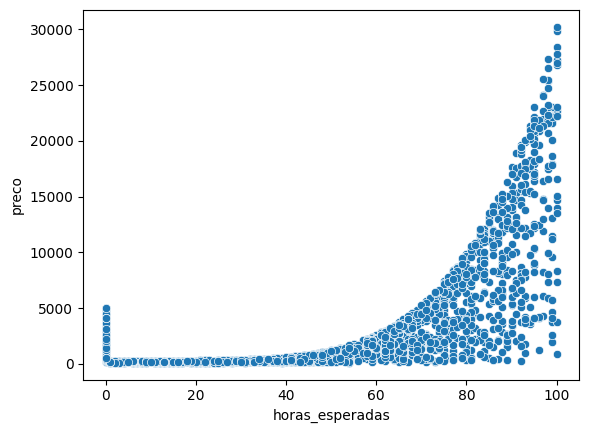

In [73]:
# entender como o preco e as horas_esperadas se relacionam. Para isso, vamos plotar um gráfico com horas_esperadas no eixo X e preco no eixo Y.
import seaborn as sns
sns.scatterplot(x="horas_esperadas", y="preco", data=dados)

O gráfico de difusão mostra uma curva interessante. À medida que as horas esperadas aumentam, o preço que a pessoa se dispôs a pagar também aumenta. Parece fazer sentido.

Se alguém está pedindo um projeto que vai demorar um ano, parece ser natural que esteja disposto a pagar mais do que quem acha que tem um projeto que vai demorar uma semana.

No entanto, parece também ter algumas pessoas que colocam um preço muito baixo para um projeto que vai demorar muito tempo. Parece que temos algumas pessoas sem noção na hora de fazer a oferta do trabalho que estão buscando alguém para executar.

A análise também é um processo natural ao se trabalhar com aprendizado de máquina. Para extrair o que gostariamos, foi preciso fazer a manipulação e exploração dos dados, processos muito comuns em ciência de dados.

Também é interessante notar que para zero horas esperadas, temos muitas pessoas dispostas a pagar de zero a 5 mil reais. Com zero horas esperadas, só sabemos o preço que a pessoa disponibilizou a pagar. Uma hipótese é que isso provavelmente não nos indica nada.

<Axes: xlabel='horas_esperadas', ylabel='preco'>

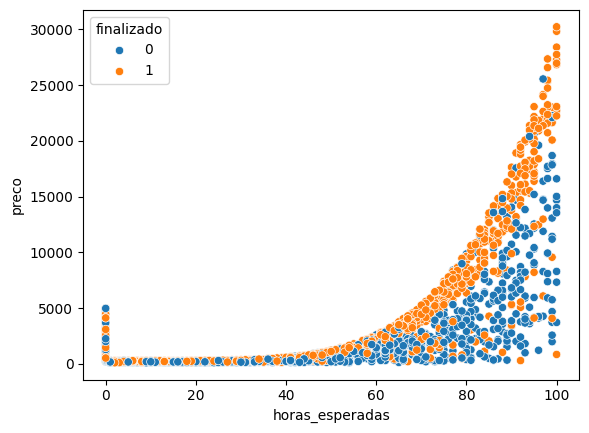

In [74]:
# explorar esse mesmo gráfico, mas sabendo quem são as pessoas que tiveram o projeto finalizado. Provavelmente, serão as pessoas dispostas a pagar mais.
# Podemos tornar as bolinhas da dispersão coloridas. Para isso, vamos usar o mesmo código do scatterplot(), mas vamos pedir para o Seaborn colorir de acordo com a coluna finalizado através do parâmetro hue.
# O gráfico indica que quem está disposto a pagar mais, tem o projeto finalizado. Quem está disposto a pagar pouco pelo número de horas trabalhadas, tem menos chances do projeto ser finalizado.
sns.scatterplot(x="horas_esperadas", y="preco", data=dados, hue="finalizado")

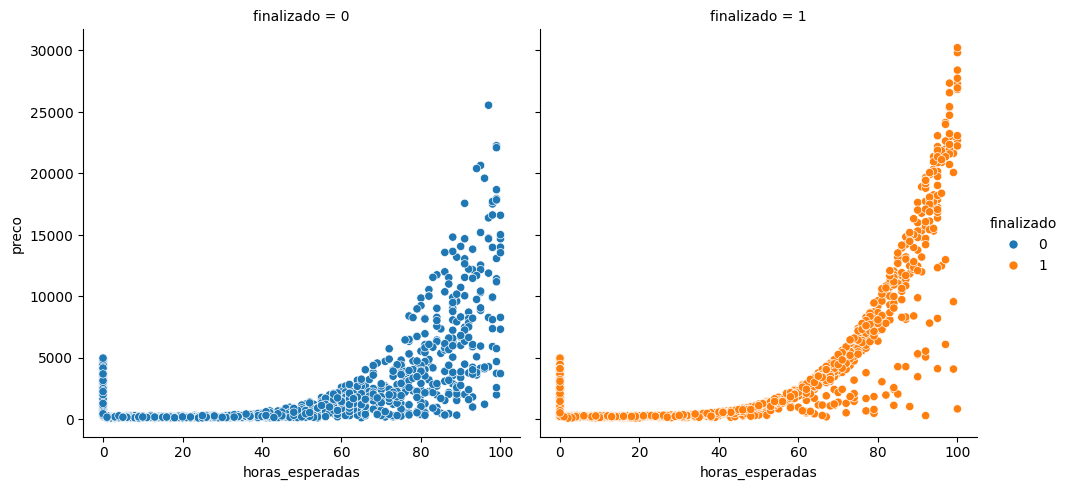

In [75]:
# Além de colorir os projetos finalizados e não-finalizados, podemos separar as curvas laranja e azul em duas colunas. Para isso, vamos usar a função relplot() do Seaborn, que permite criar gráficos de relacionamento.
# Ademais dos parâmetros de x, y, data e hue, vamos acrescentar o parâmetro col igual a finalizado.
sns.relplot(x="horas_esperadas", y="preco", data=dados, hue="finalizado", col="finalizado")

O gráfico mostra que realmente, a curva de finalizado é uma fatia, quem paga bem o suficiente para aquele número de horas. E os projetos não finalizados, tem de tudo.

Podemos usar o modelo de aprendizado de máquina para avaliar a chance de conclusão do projeto com base no número estimado de horas para execução e o valor que a pessoa está disposta a pagar. Assim, seria possível calibrar o quanto você quer pagar de acordo com o que o mercado está disposto a aceitar por aquele trabalho.

In [76]:
# Excluindo projetos sem horas esperadas
# jogar fora as linhas com horas_esperadas = 0
# parece haver uma mistura de resultados quando o número de horas esperadas é zero. Afinal, se apenas colocamos o preço, não temos a informação de quantas horas o projeto pode demorar.
# Então, talvez seja preciso jogar fora os dados de quem tem as horas_esperadas igual a zero, devido a pouca de informação.
dados = dados.query("horas_esperadas > 0")
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizado
0,0,75.0,6985.0,1
2,0,87.0,14205.0,1
3,1,13.0,100.0,0
4,0,2.0,202.0,1
5,0,49.0,1096.0,1


Treinando o modelo de duas dimensões:

In [77]:
# Nesse caso, x conterá as colunas horas_esperadas e preco do dataframe de dados; enquanto o y, será somente a coluna finalizado.
x = dados[["horas_esperadas", "preco"]]
y = dados["finalizado"]

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

SEED = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y,
                                                         random_state = SEED,
                                                         stratify = y)
print(f"Treinaremos com {len(treino_x)}")
print(f"Testaremos com {len(teste_x)}")

modelo = LinearSVC()
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {acuracia:.2f}%")

Treinaremos com 1617
Testaremos com 540
A acurácia foi de 60.56%


Após executar o código, descobrimos que a acurácia do modelo foi de 62,41%. Esse número é bom ou ruim? Não sabemos. Depende dos nossos dados.

Por exemplo, se estamos prevendo a aparição de um tipo de câncer que só aparece em 1% da população, acertar 10% das vezes é considerado baixo.

Uma base que podemos utilizar para o nosso exemplo é saber quantos projetos foram finalizados. Ou seja, quantas vezes no nosso algoritmo de teste, no teste_y, o finalizado é 1. Se chutarmos que tudo é 1, quantas vezes acertamos?

Primeiro, vamos fazer a soma do teste_y divido pelo seu tamanho. Isto é, teste_y.sum() / len(teste_y).

In [79]:
# Se multiplicamos o resultado por 100, teremos uma porcentagem de 52%. Esse é o algoritmo base, onde supomos que todo mundo finalizou o projeto.
teste_y.sum() / len(teste_y)

np.float64(0.5259259259259259)

In [80]:
previsoes_de_base = teste_y.sum() / len(teste_y) * 100
print(f"A acurácia do modelo de base foi de {previsoes_de_base:.2f}%")

A acurácia do modelo de base foi de 52.59%


A acurácia do modelo foi de 62%, ou seja, está um pouco melhor do que o algoritmo de base. Poderia ficar muito melhor? Não sabemos, é preciso testar. Pelo menos, agora, temos uma base.

Lembrando que só estamos trabalhando com os dados em que a pessoa preenche as horas esperadas.

conseguimos chegar a 62% de acurácia. Parece um número bom, mas será que isso pode ser aplicado no mundo real?

Acertar se o projeto será finalizado dois terços das vezes é útil? Errar um terço das vezes pode deixar sua clientela irritada. Em um contexto mais grave, como na saúde, esse número pode ser ruim. Tudo depende do cenário.

É comum se ter um algoritmo base, uma heurística simples, como a suposição de que todo mundo finalizou o projeto que teve uma acurácia de 52%. Também é normal ter um primeiro modelo que não está muito melhor ou está até pior.

Precisamos entender o que está dando errado no modelo e o que ele não está conseguindo aprender. A partir disso, podemos melhorar esse modelo, ajustando os parâmetros ou escolhendo outro que aprenda melhor os padrões dos nossos dados.

# Melhorando o modelo

o gráfico de dispersão para entender a relação entre horas esperadas e preço, descobrimos que vários projetos finalizados e não-finalizados.

Nosso algoritmo consegue executar o predict() para qualquer par de números, ou seja, vai prever 0 ou 1 para qualquer ponto desse gráfico de duas dimensões (2D). Afinal, essa é a função matemática que criamos com o modelo.

Seria interessante plotar tanto o teste que está falhando quanto a previsão para os outros pontos em branco. Assim, poderemos entender quais partes desse espaço em branco o modelo está prevendo que pode ser finalizado.

Com isso, conseguiremos visualizar a explicação por trás de modelos de duas dimensões em uma, como o Linear SVC e outros modelos semelhantes.

In [81]:
import sklearn
print(sklearn.__version__)

1.7.1


Construindo a grade

definir os valores mínimos e máximos de x e y. Assim como no gráfico anterior, vamos usar horas esperadas e preço como limites dos eixos horizontais e verticais, respectivamente.

Desse modo, para x_min, vamos trabalhar com o valor mínimo de horas esperadas. Já para x_max, queremos o máximo de horas esperadas. Enquanto para y_min, usaremos o mínimo do preço e, para y_max, usaremos o máximo do preço.

Estamos interessados nos valores do teste, e não de treino, já que queremos analisar o que está acontecendo no espaço de teste.

In [82]:
x_min = teste_x["horas_esperadas"].min()
x_max = teste_x["horas_esperadas"].max()
y_min = teste_x["preco"].min()
y_max = teste_x["preco"].max()

In [83]:
print(f"x_min: {x_min}")
print(f"x_max: {x_max}")
print(f"y_min: {y_min}")
print(f"y_max: {y_max}")

x_min: 1.0
x_max: 100.0
y_min: 102.0
y_max: 30223.0


plotaremos um gráfico que vai de 1 a 100 horas e de 102 a 30 mil reais.

Nesse caso, construiremos uma grade de 100x100 pixels, totalizando 10 mil pontos. Por isso, definimos pixels igual a 100. Será preciso calcular a previsão (predict) para cada um dos pontos desse gráfico - o que pode levar algum tempo.

Precisamos de 100 pontos tanto para o eixo x quanto para o eixo y. Para gerar todos de uma única vez, utilizamos uma função do NumPy chamada arange(). Antes, é preciso importar a biblioteca através do import numpy as np.

In [84]:
import numpy as np

pixels = 100

In [85]:
eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)

 o eixo_x será um array de 1.00 a 99.01, em intervalos por volta de 1. Enquanto o eixo_y vai de 102.00 a 29921.79, em intervalos por volta de 300. Note que ambos excluem o valor máximo. Isso será suficiente para a nossa visualização.

Depois de criar os 100 pontos dos eixos horizontais e verticais, precisamos cruzar todos os possíveis pares de x e y. Para fazer essa mescla dos eixos, podemos usar a função meshgrid() do Numpy.

Assim, np.meshgrid() combinará eixo_x e eixo_y. Esse resultado será armazenado em xx, yy. Basicamente, o Numpy vai pegar o eixo x e repetir cada valor 100 vezes, e, depois, fará o mesmo para o eixo y.

In [86]:
xx, yy = np.meshgrid(eixo_x, eixo_y)

In [87]:
# xx.ravel() e yy.ravel() para juntar todos os valores e, criar pares com o np.c_
# Os pares serão armazenados na variável chamada pontos. Podemos visualizá-los, mas como são números grandes, estarão com a notação científica.
# Com isso, temos cada um dos pixels em uma grade de 100x100 pixels.
pontos = np.c_[xx.ravel(), yy.ravel()]
pontos

array([[1.000000e+00, 1.020000e+02],
       [1.990000e+00, 1.020000e+02],
       [2.980000e+00, 1.020000e+02],
       ...,
       [9.703000e+01, 2.992179e+04],
       [9.802000e+01, 2.992179e+04],
       [9.901000e+01, 2.992179e+04]], shape=(10000, 2))

In [88]:
# chamar o modelo.predict(pontos) para obter as previsões para cada ponto da grade. Por padrão, esse resultado será o Z, que representa as previsões para todo o grid.
Z = modelo.predict(pontos)

c:\Users\RedSeek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


In [89]:
# A grade está literalmente em uma única sequência, então, precisamos transformá-la para o formato de 100x100.
# Como os pixels são 100, o xx já tem esse formato de 100x100. Então, com a função reshape(), podemos reformular o Z para ter o mesmo formato de xx, ou seja, xx.shape.
Z = Z.reshape(xx.shape)
Z

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(100, 100))

# Analisando curva de decisão

In [90]:
import matplotlib.pyplot as plt

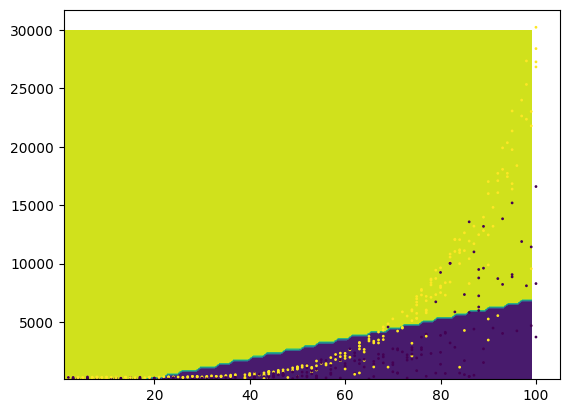

In [91]:
# Imprimir um contorno de uma função usando plt.contourf(). Contornamos uma função no xx e yy de acordo com as cores de Z.
# Para comparar o resultado, também plotaremos o gráfico de dispersão de horas esperadas e preço dos dados de teste. Nessa função scatter(), 
# vamos acrescentar o parâmetro z igual a 1 para diminuir o tamanho (size) dos pontos.

plt.contourf(xx, yy, Z)
plt.scatter(teste_x["horas_esperadas"], teste_x["preco"], c=teste_y, s=1)

criamos uma curva que define qual projeto será ou não finalizado. Na parte inferior, na cor roxa, estão os projetos previstos como não-finalizados. E, na parte de cima em amarelo, estão os projetos previstos como finalizados.

O algoritmo encontrou uma curva bem ruim, porque é quase uma reta - se comparada a curva crescente do gráfico de dispersão com os dados de projetos reais. Isso significa que vários projetos que não foram finalizados, foram estimados como finalizados.

Conclusão:
Com essa abordagem, conseguimos traçar uma curva de decisão, onde a função para de jogar os valores 0 e passa a jogar os valores 1, ou vice-versa.

No entanto, a curva encontrada está muito reta - o que indica que o modelo usado não consegue aprender o comportamento esperado. Em outras palavras, o modelo linear SVC é incapaz de capturar a relação não-linear presente nos dados.

# Estimadores não lineares e Support Vector Machine

Um espaço 2D representando preço e horas. Esse modelo matemático traça uma linha que corta o espaço ao meio. Tudo que estiver abaixo da linha recebe uma classificação zero e tudo que estiver acima recebe um, ou vice-versa.

No entanto, sabemos que a relação entre esses elementos não é linear, mas sim curvilínea. Portanto, precisamos de um modelo capaz de aprender padrões curvos. Com o avanço da inteligência artificial e do aprendizado de máquina, foram desenvolvidos modelos que conseguem identificar relações não lineares. Vamos explorar um desses modelos agora.

Um exemplo bastante conhecido é o sklearn svm SVC. Então, abrimos o navegador e fazemos essa busca. Anteriormente, usamos o LinearSVC, que trabalha com padrões lineares. Mas, também existe o SVC, que permite trabalhar com estratégias não necessariamente lineares, utilizando a support vector machines, máquinas de vetores de suporte. Ambos utilizam essa abordagem, mas o LinearSVC é restrito ao linear, enquanto o SVC é mais flexível. É justamente o SVC que vamos utilizar agora.

In [92]:
# Alteração para o SVC 

# Primeiro, vamos refazer o treinamento, dividindo os dados em treino e teste. Então, no Google Colab, subimos algumas células até encontrar onde fizemos a separação e executamos o LinearSVC. 
# Feito isso, copiamos todo o código com "Ctrl + C". Após, na parte superior da tela, clicamos no botão "+ Texto" para criar uma célula de texto e digitamos SVC. Após, colamos o código com "Ctrl + V".
# Agora, faremos as alterações necessárias. Em todo o código, mudamos de LinearSVC para SVC. Após, executamos a célula.
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

SEED = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y,
                                                         random_state = SEED,
                                                         stratify = y)
print(f"Treinaremos com {len(treino_x)}")
print(f"Testaremos com {len(teste_x)}")

modelo = SVC()
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {acuracia:.2f}%")

Treinaremos com 1617
Testaremos com 540
A acurácia foi de 56.67%


Assim, temos o seguinte retorno:

Treinaremos com 1617 Testaremos com 540 A acurácia foi de 56.67%

Fazendo uma comparação, o resultado anterior era 62.41%. Se rodarmos de novo, o valor se mantém. Lembrando que a seed está fixa, não afirmamos que iria melhorar de imediato, mas sim que precisávamos de um modelo capaz de aprender padrões mais complexos. Esse é o nosso desafio.

c:\Users\RedSeek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


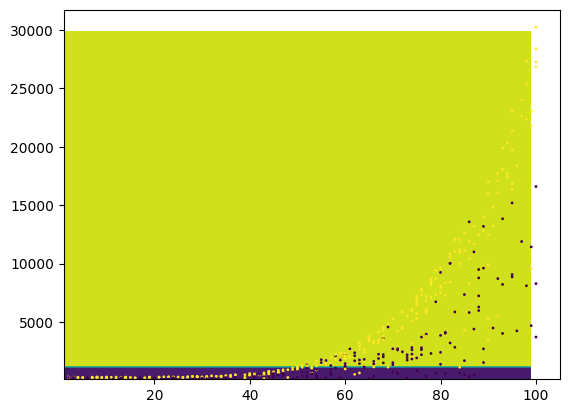

In [93]:
# Como estamos usando um modelo mais avançado, precisamos garantir que ele funcione corretamente. Mas, primeiro, vamos analisar o que ele aprendeu, observando a curva de decisão, e definiu como valores 1 e 0.
# Para isso, vamos copiar o trecho do código de x_min até y_max e colamos em uma nova célula. Após, copiamos o trecho de código de código referente ao eixo_x e eixo_y e colamos na mesma célula.
# Fazemos o mesmo com todos os outros trechos de código, sendo o trecho de código xx, yy, seguido de Z e o plt. Após, apagamos os import, pois eles já foram feitos. O código fica da seguinte forma:

x_min = teste_x["horas_esperadas"].min()
x_max = teste_x["horas_esperadas"].max()
y_min = teste_x["preco"].min()
y_max = teste_x["preco"].max()

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(teste_x["horas_esperadas"], teste_x["preco"], c=teste_y, s=1)

c:\Users\RedSeek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


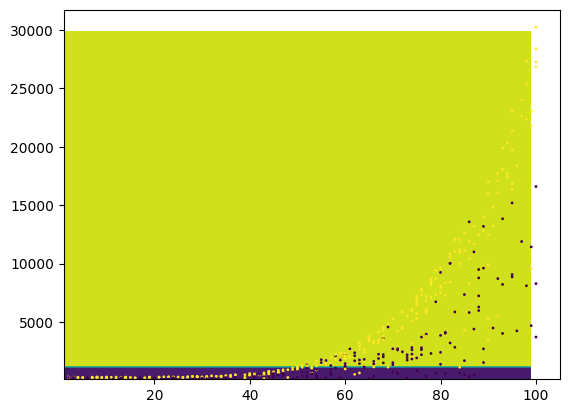

In [94]:
x_min = teste_x["horas_esperadas"].min()
x_max = teste_x["horas_esperadas"].max()
y_min = teste_x["preco"].min()
y_max = teste_x["preco"].max()

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(teste_x["horas_esperadas"], teste_x["preco"], c=teste_y, s=1)

c:\Users\RedSeek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


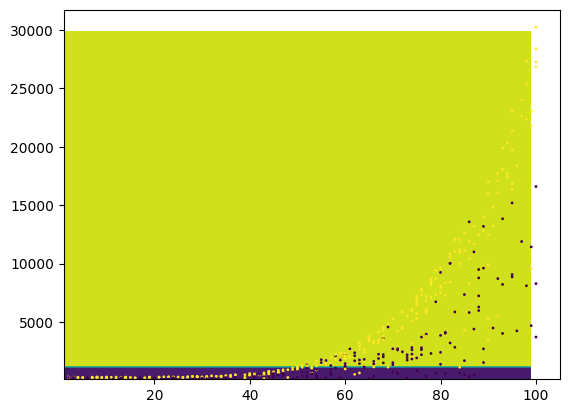

In [95]:
x_min = teste_x["horas_esperadas"].min()
x_max = teste_x["horas_esperadas"].max()
y_min = teste_x["preco"].min()
y_max = teste_x["preco"].max()

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(teste_x["horas_esperadas"], teste_x["preco"], c=teste_y, s=1)

Exploração dos Parâmetros do SVC

In [96]:
# O parametros Gamma, foi alterado de auto para scale como padrão. 
# O resultado é bem diferente do grafico. 
# Treinaremos com 1617 Testaremos com 540 A acurácia foi de 57.78%
# Vemos pequenas formas, como elipses, que delimitam as áreas onde ele classificou como 1, enquanto o restante foi classificado como 0. 
# Então, já não é mais um comportamento de uma única linha, não é linear de separar um espaço.
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

SEED = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y,
                                                         random_state = SEED,
                                                         stratify = y)
print(f"Treinaremos com {len(treino_x)}")
print(f"Testaremos com {len(teste_x)}")

modelo = SVC(gamma='auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {acuracia:.2f}%")

Treinaremos com 1617
Testaremos com 540
A acurácia foi de 57.78%


c:\Users\RedSeek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


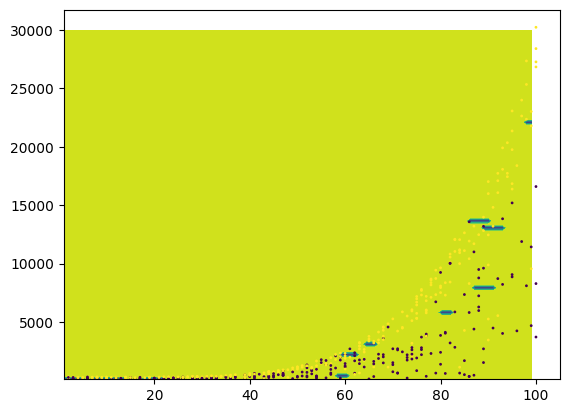

In [97]:
#plotando o Grafico apos alteraçao do parametro do SVC Gamma, onde foi alterado de auto para scale
x_min = teste_x["horas_esperadas"].min()
x_max = teste_x["horas_esperadas"].max()
y_min = teste_x["preco"].min()
y_max = teste_x["preco"].max()

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(teste_x["horas_esperadas"], teste_x["preco"], c=teste_y, s=1)

Vemos pequenas formas, como elipses, que delimitam as áreas onde ele classificou como 1, enquanto o restante foi classificado como 0. 

Então, já não é mais um comportamento de uma única linha, não é linear de separar um espaço.

# Considerações sobre a escala e normalização

Estamos fazendo isso no 2D, no 3D seria um corte bidimensional mais complexo. Mas, a ideia é cortar o espaço no meio e definir que o corte não é uma linha reta e sim subespaços dentro do espaço.

Agora que colocamos que o parâmetro gamma é automático, ele não é mais linear, conseguimos encontrar um modelo que aprenderá comportamentos não lineares, mas ainda não está bom.

Precisamos ganhar conhecimento dos modelos para escolher os parâmetros que achamos, ou explorar diversos parâmetros. Lembrando que tudo o que estamos falando nesse vídeo é um universo para se aprofundar.

Ainda há algo errado. Notem que o modelo parece estar dando uma ênfase estranha, como se estivesse um pouco esticado para a direita. A escala do nosso gráfico vai de 0 a 100 no eixo horizontal e de 0 a 30 mil no eixo vertical.

Isso lembra uma situação em que alguém comenta que um Big Mac nos Estados Unidos é muito mais caro, dizendo que custa 30 dólares em comparação com 5 dólares no Brasil, sem considerar a conversão entre o real e o dólar. É importante lembrar que existe um fator de conversão, pois são escalas diferentes.

O custo de vida também varia entre países. No Brasil, existe uma escala, nos Estados Unidos outra, assim como na Europa e assim por diante. Se compararmos números diferentes, como peso e altura, notamos que são grandezas distintas e, portanto, não faz sentido comparar metros com quilos, e essa falta de sentido pode se aplicar a alguns algoritmos.

Muitos algoritmos podem ser influenciados por essas diferenças de escala. Se temos escalas distintas, o algoritmo pode dar mais peso para os valores maiores, influenciando os resultados de forma inesperada. Isso pode causar uma confusão nos resultados, especialmente quando não sabemos qual fator deve ter mais peso, se é o valor que oferecemos ou o número de horas estimadas para a execução.

Se não definirmos a escala de cada variável, o algoritmo pode acabar direcionando suas conclusões para um lado ou para o outro de maneira equivocada. Então, como é que fazemos para colocar todos eles na mesma escala?

# Normalização dos Dados

Para determinar se estamos acima da média de peso de todas as pessoas do Brasil, primeiro calculamos a média do peso de toda a população e dividimos pelo número total de pessoas para obter a média. Da mesma forma, se sua altura estiver 3 centímetros abaixo da média, isso é apenas uma diferença em relação à média.

O objetivo de fazer essas comparações é verificar como estamos em relação à média, o que pode ajudar em previsões e análises. Independente da escala dos dados, precisamos normalizá-los para comparações significativas. Isso envolve mais do que apenas calcular a média. Devemos normalizar os dados, aplicando técnicas de normalização que ajustam a escala dos valores. Usaremos uma técnica comum de normalização, a re-escalação padrão, para transformar os valores padronizadamente.

Queremos que o eixo x e y estejam no mesmo tipo de escala, para não influenciar o algoritmo. Para isso, copiamos o mesmo trecho de código que usamos anteriormente e que faz a distribuição.

Após separarmos os dados em treino e teste, é fundamental lembrar que, não devemos usar as informações do teste durante o treinamento. Portanto, o primeiro passo prático deve ser a separação dos dados antes de qualquer exploração adicional.

Queremos transformar a escala. Então, no início do código, adicionamos from sklearn.preprocessing import StandardScaler. No fim do código, passamos scaler = StandardScaler(), seguido de scaler.fit(treino_x).

Após treinar como as coisas funcionam, precisamos reescalar, ou seja, pegar todos os dados do treino que foram calculadas as médias e pedir para transformar os dados do treino_x.

Para não confundirmos com o treino_x do início do código, mudamos ele para raw_treino_x e raw_teste_x.

Assim, treinaremos o "escalador", conforme os dados raw_treino_x. Ele aprenderá a escalar os dados. Pedimos então para reescalar tanto treino quanto teste.

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

SEED = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y,
                                                         random_state = SEED,
                                                         stratify = y)
print(f"Treinaremos com {len(raw_treino_x)}")
print(f"Testaremos com {len(raw_teste_x)}")

scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo = SVC(gamma='auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {acuracia:.2f}%")

Treinaremos com 1617
Testaremos com 540
A acurácia foi de 68.52%


Após rodar o modelo, notamos que a acurácia é de 68%, a maior até agora, melhorou bastante. Vamos conferir qual foi a curva que ela aprendeu.

Para isso, copiamos a célula anterior, copiamos e colamos em uma nova. Feito isso, rodamos o código novamente, assim temos um erro. Isso acontece, pois o teste_x foi passado pelo StandardScaler, então não é mais do pandas. Antes ele tinha a coluna horas esperadas, agora não tem mais.

# Análise da Curva Aprendida

In [99]:
# Para descobrirmos o que ele é, passamos teste_x em uma nova célula e executamos.

teste_x

array([[ 1.21903398, -0.51627687],
       [ 0.868926  ,  0.53984011],
       [ 0.13369924, -0.4353314 ],
       ...,
       [ 1.74419595,  2.72476393],
       [ 0.23873164, -0.22249714],
       [-0.63653831, -0.53661392]], shape=(540, 2))

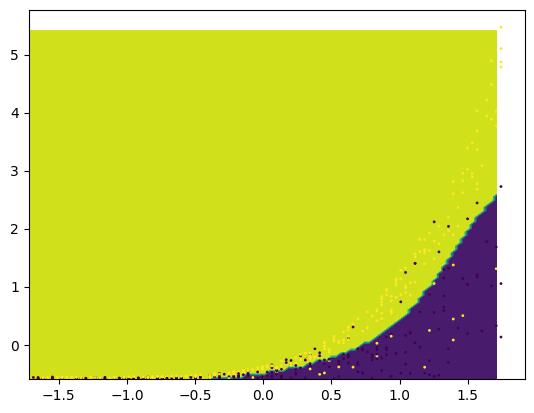

In [100]:
data_col1 = teste_x[:, 0]
data_col2 = teste_x[:, 1]

x_min = data_col1.min()
x_max = data_col1.max()
y_min = data_col2.min()
y_max = data_col2.max()

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(data_col1, data_col2, c=teste_y, s=1)

O algoritmo aprendeu essa curva roxa, assim a taxa de acerto aumenta muito. Perceba que precisamos conhecer os modelos que estamos utilizando e os que está disponíveis e isso acontece com o tempo.

Como pessoa desenvolvedora você vai se especializando gradualmente, aprofundando seu conhecimento sobre diferentes modelos e técnicas de treinamento. Com o passar do tempo você vai estudando mais sobre cada modelo, explorando otimizações e ajustando suas estratégias.

Criamos propositalmente esse caminho para mostrar que diferentes modelos resolvem problemas distintos. Para saber qual modelo usar, é essencial conhecer bem cada um deles. Com a experiência, você desenvolve a intuição para escolher o modelo mais adequado para cada situação. Isso envolve explorar diferentes parâmetros e ajustar suas abordagens conforme necessário.

No nosso caso, o modelo SVC conseguiu aprender uma relação não linear entre as variáveis, que era exatamente o que precisávamos.